In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [38]:
import pandas as pd

usuarios_activos = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_actualizado.csv')
usuarios_eliminados = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_actualizado.csv')

# Eliminar columnas no necesarias
usuarios_activos = usuarios_activos.drop(columns=['deleted_account_id'], errors='ignore')
usuarios_eliminados = usuarios_eliminados.drop(columns=['user_id'], errors='ignore')

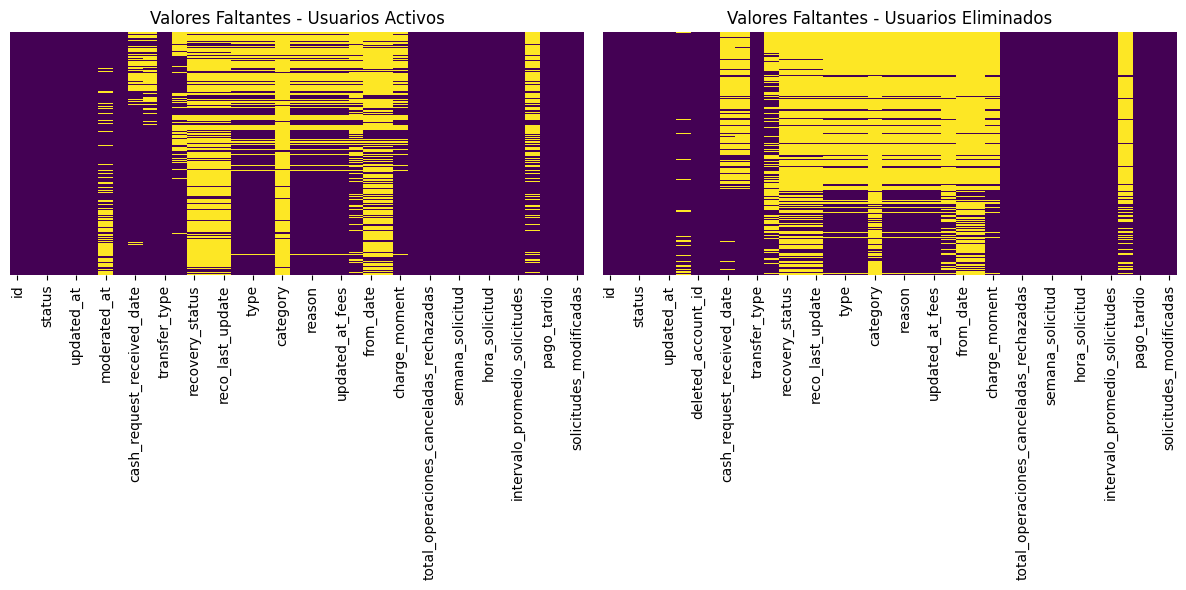

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del tamaño de las figuras
plt.figure(figsize=(12, 6))

# Mapa de calor para usuarios_activos
plt.subplot(1, 2, 1)
sns.heatmap(usuarios_activos.isnull(), cmap='viridis', cbar=False, yticklabels=False)
plt.title('Valores Faltantes - Usuarios Activos')

# Mapa de calor para usuarios_eliminados
plt.subplot(1, 2, 2)
sns.heatmap(usuarios_eliminados.isnull(), cmap='viridis', cbar=False, yticklabels=False)
plt.title('Valores Faltantes - Usuarios Eliminados')

# Mostrar gráficos
plt.tight_layout()
plt.show()


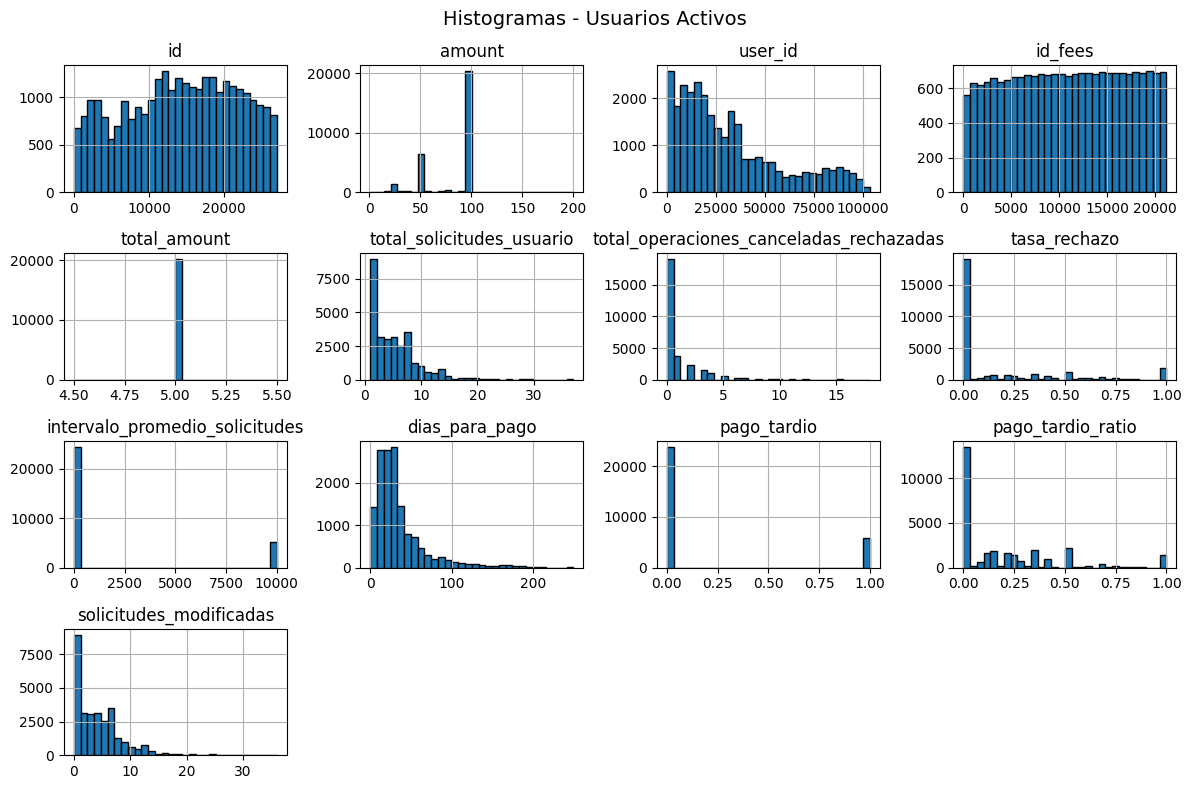

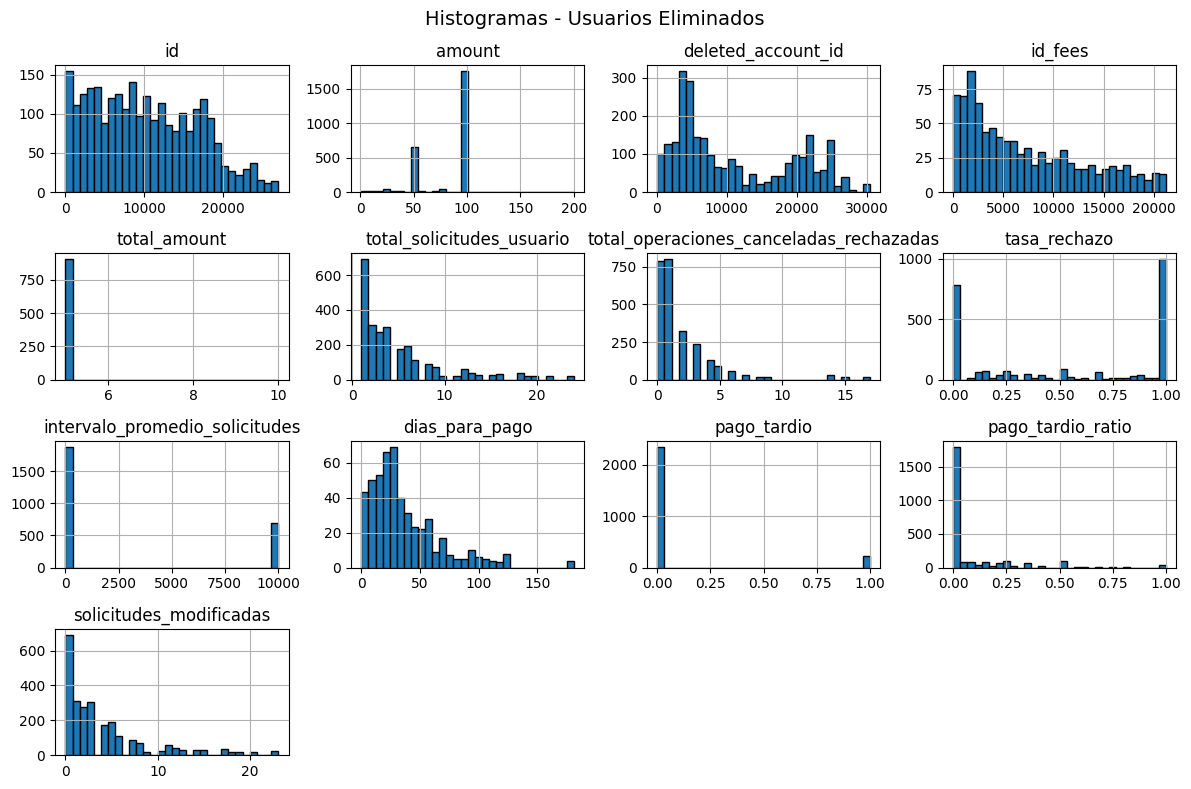

In [39]:
import matplotlib.pyplot as plt

# Función para graficar histogramas de columnas numéricas
def graficar_histogramas(df, titulo):
    columnas_numericas = df.select_dtypes(include=['number']).columns
    df[columnas_numericas].hist(figsize=(12, 8), bins=30, edgecolor='black')
    plt.suptitle(titulo, fontsize=14)
    plt.tight_layout()
    plt.show()

# Histogramas para usuarios_activos
graficar_histogramas(usuarios_activos, 'Histogramas - Usuarios Activos')

# Histogramas para usuarios_eliminados
graficar_histogramas(usuarios_eliminados, 'Histogramas - Usuarios Eliminados')


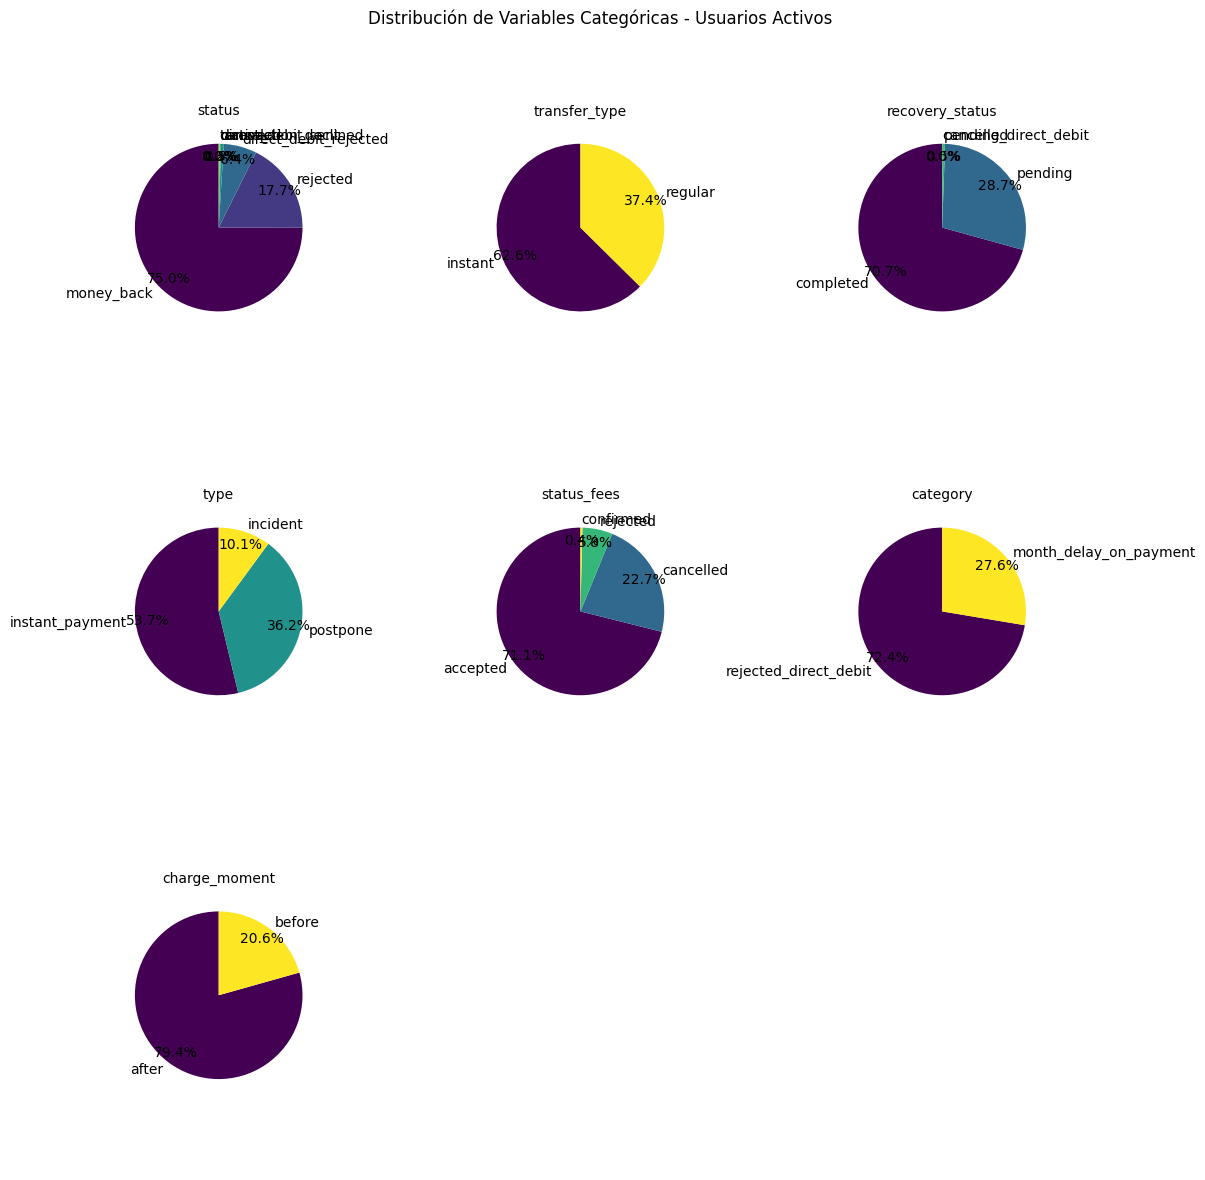

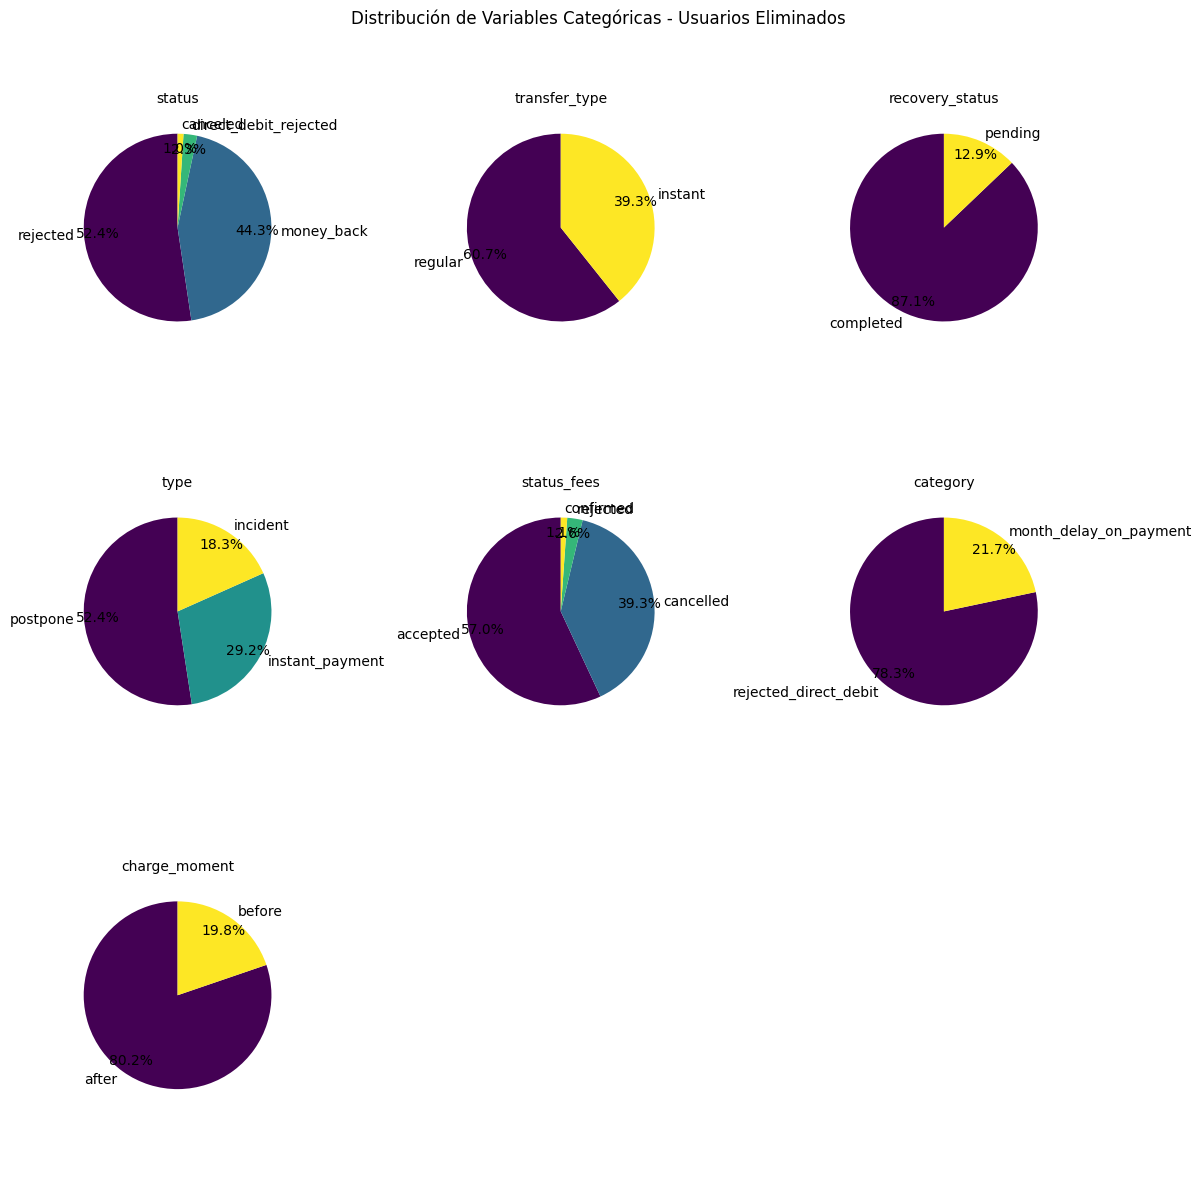

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Función para graficar distribuciones en gráficos circulares organizados en varias columnas
def graficar_pie_charts(df, titulo, max_cols=3):
    # Seleccionar variables categóricas relevantes (evitar columnas con demasiados valores únicos)
    columnas_categoricas = [col for col in df.select_dtypes(include=['object']).columns if df[col].nunique() <= 10]

    if not columnas_categoricas:
        print(f"No hay columnas categóricas relevantes en {titulo}")
        return

    num_vars = len(columnas_categoricas)
    num_cols = min(num_vars, max_cols)  # Determinar el número de columnas a usar
    num_rows = int(np.ceil(num_vars / num_cols))  # Determinar filas necesarias

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4*num_cols, 4*num_rows))
    axes = np.array(axes).reshape(-1)  # Asegurar que sea un array 1D para iteración

    for i, columna in enumerate(columnas_categoricas):
        ax = axes[i]
        df[columna].value_counts().plot.pie(
            ax=ax, autopct='%1.1f%%', startangle=90, cmap='viridis', pctdistance=0.85
        )
        ax.set_title(columna, fontsize=10)
        ax.set_ylabel('')  # Ocultar etiqueta Y

    # Ocultar gráficos vacíos si hay menos categorías que espacios asignados
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Distribución de Variables Categóricas - {titulo}', fontsize=12)
    plt.tight_layout()
    plt.show()

# Gráficos circulares para usuarios_activos
graficar_pie_charts(usuarios_activos, 'Usuarios Activos')

# Gráficos circulares para usuarios_eliminados
graficar_pie_charts(usuarios_eliminados, 'Usuarios Eliminados')


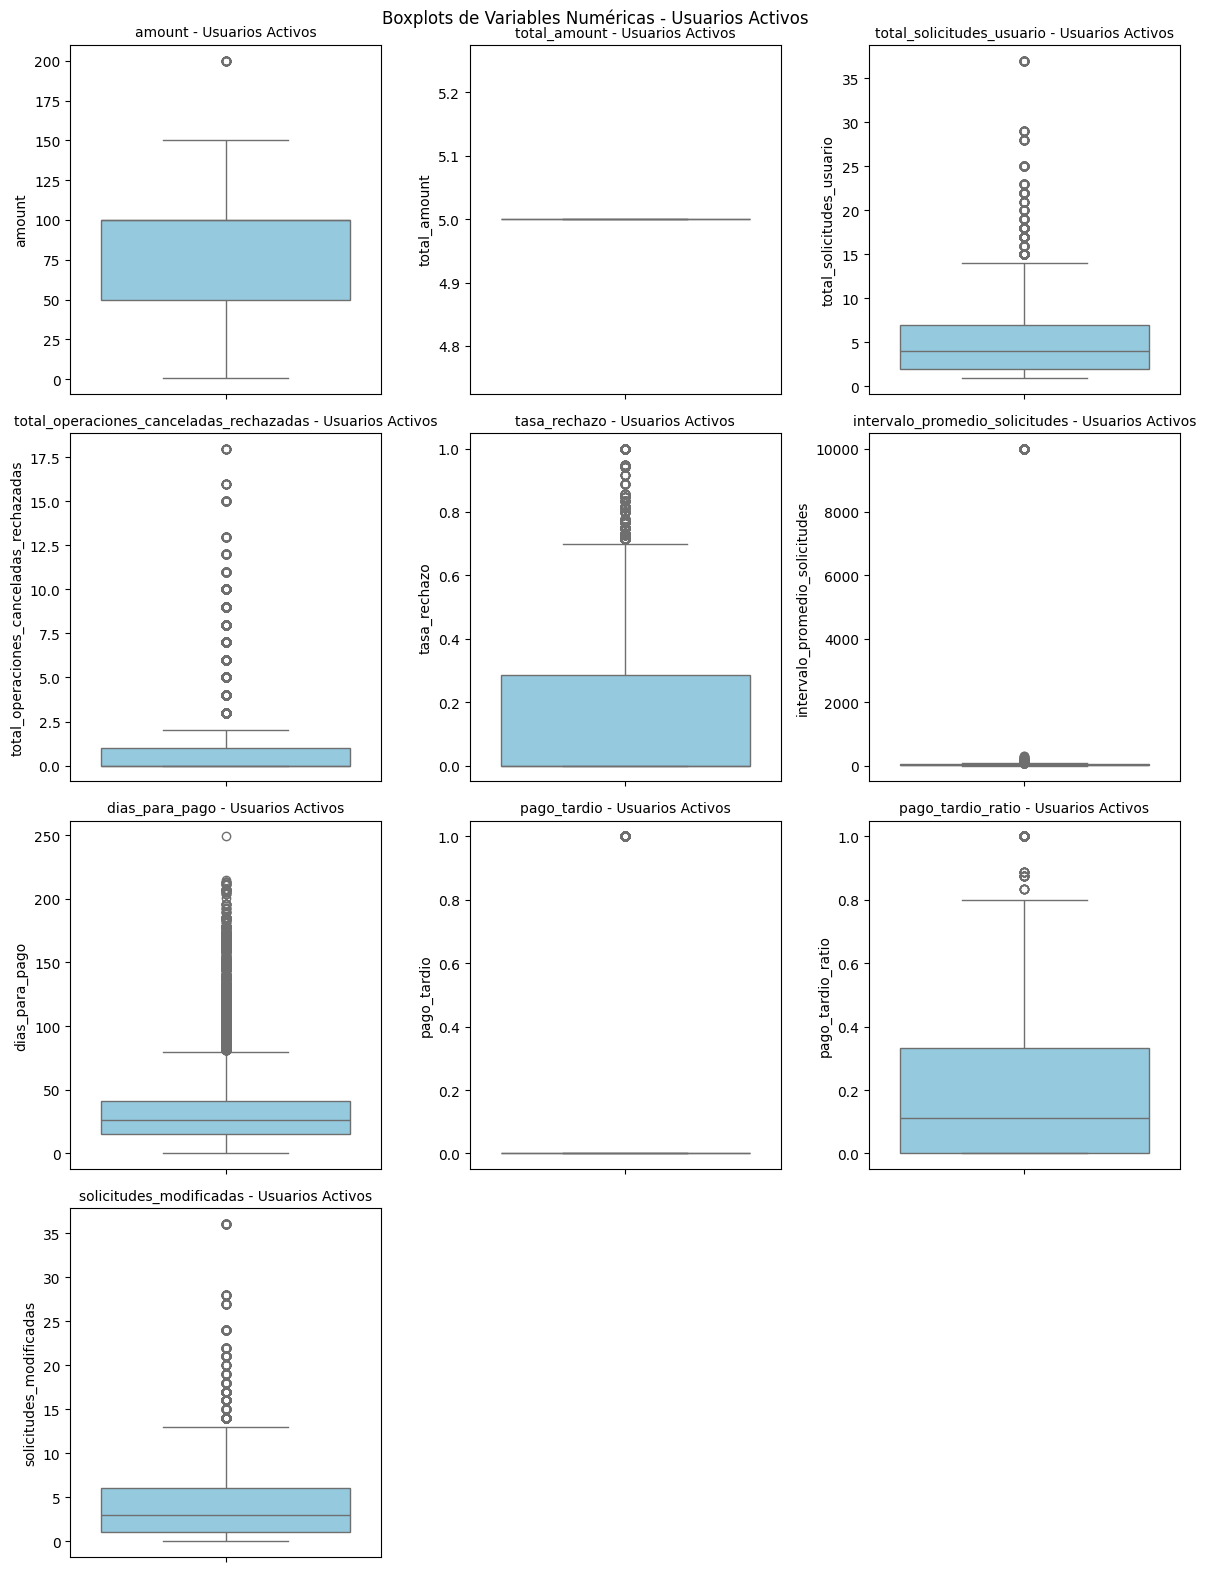

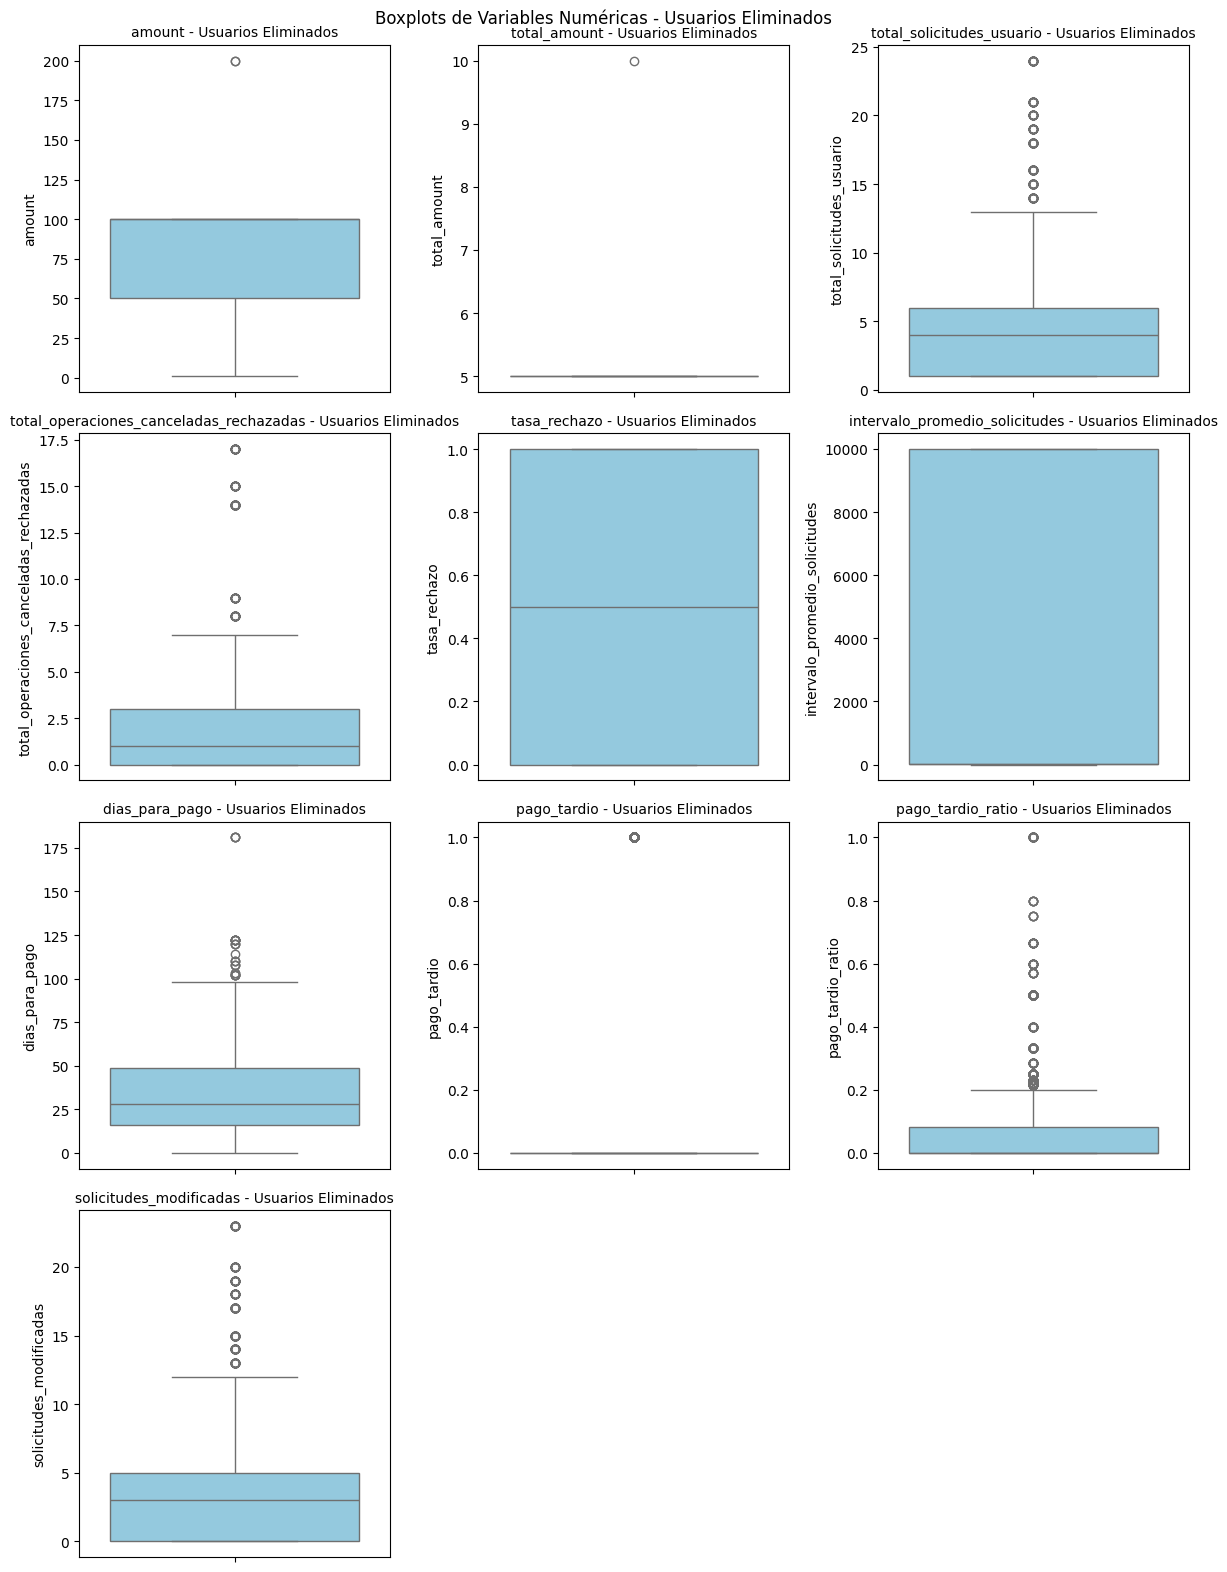

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Función para graficar boxplots de variables numéricas (excluyendo IDs)
def graficar_boxplots(df, titulo, max_cols=3):
    # Seleccionar columnas numéricas (excluyendo IDs)
    columnas_numericas = [col for col in df.select_dtypes(include=['number']).columns
                          if 'id' not in col.lower()]

    if not columnas_numericas:
        print(f"No hay columnas numéricas relevantes en {titulo}")
        return

    num_vars = len(columnas_numericas)
    num_cols = min(num_vars, max_cols)  # Determinar número de columnas
    num_rows = int(np.ceil(num_vars / num_cols))  # Determinar número de filas

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4*num_cols, 4*num_rows))
    axes = np.array(axes).reshape(-1)  # Convertir a 1D para iterar

    for i, columna in enumerate(columnas_numericas):
        sns.boxplot(y=df[columna], ax=axes[i], color='skyblue')
        axes[i].set_title(f'{columna} - {titulo}', fontsize=10)

    # Ocultar gráficos vacíos si hay menos variables de las esperadas
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Boxplots de Variables Numéricas - {titulo}', fontsize=12)
    plt.tight_layout()
    plt.show()

# Boxplots para usuarios_activos
graficar_boxplots(usuarios_activos, 'Usuarios Activos')

# Boxplots para usuarios_eliminados
graficar_boxplots(usuarios_eliminados, 'Usuarios Eliminados')



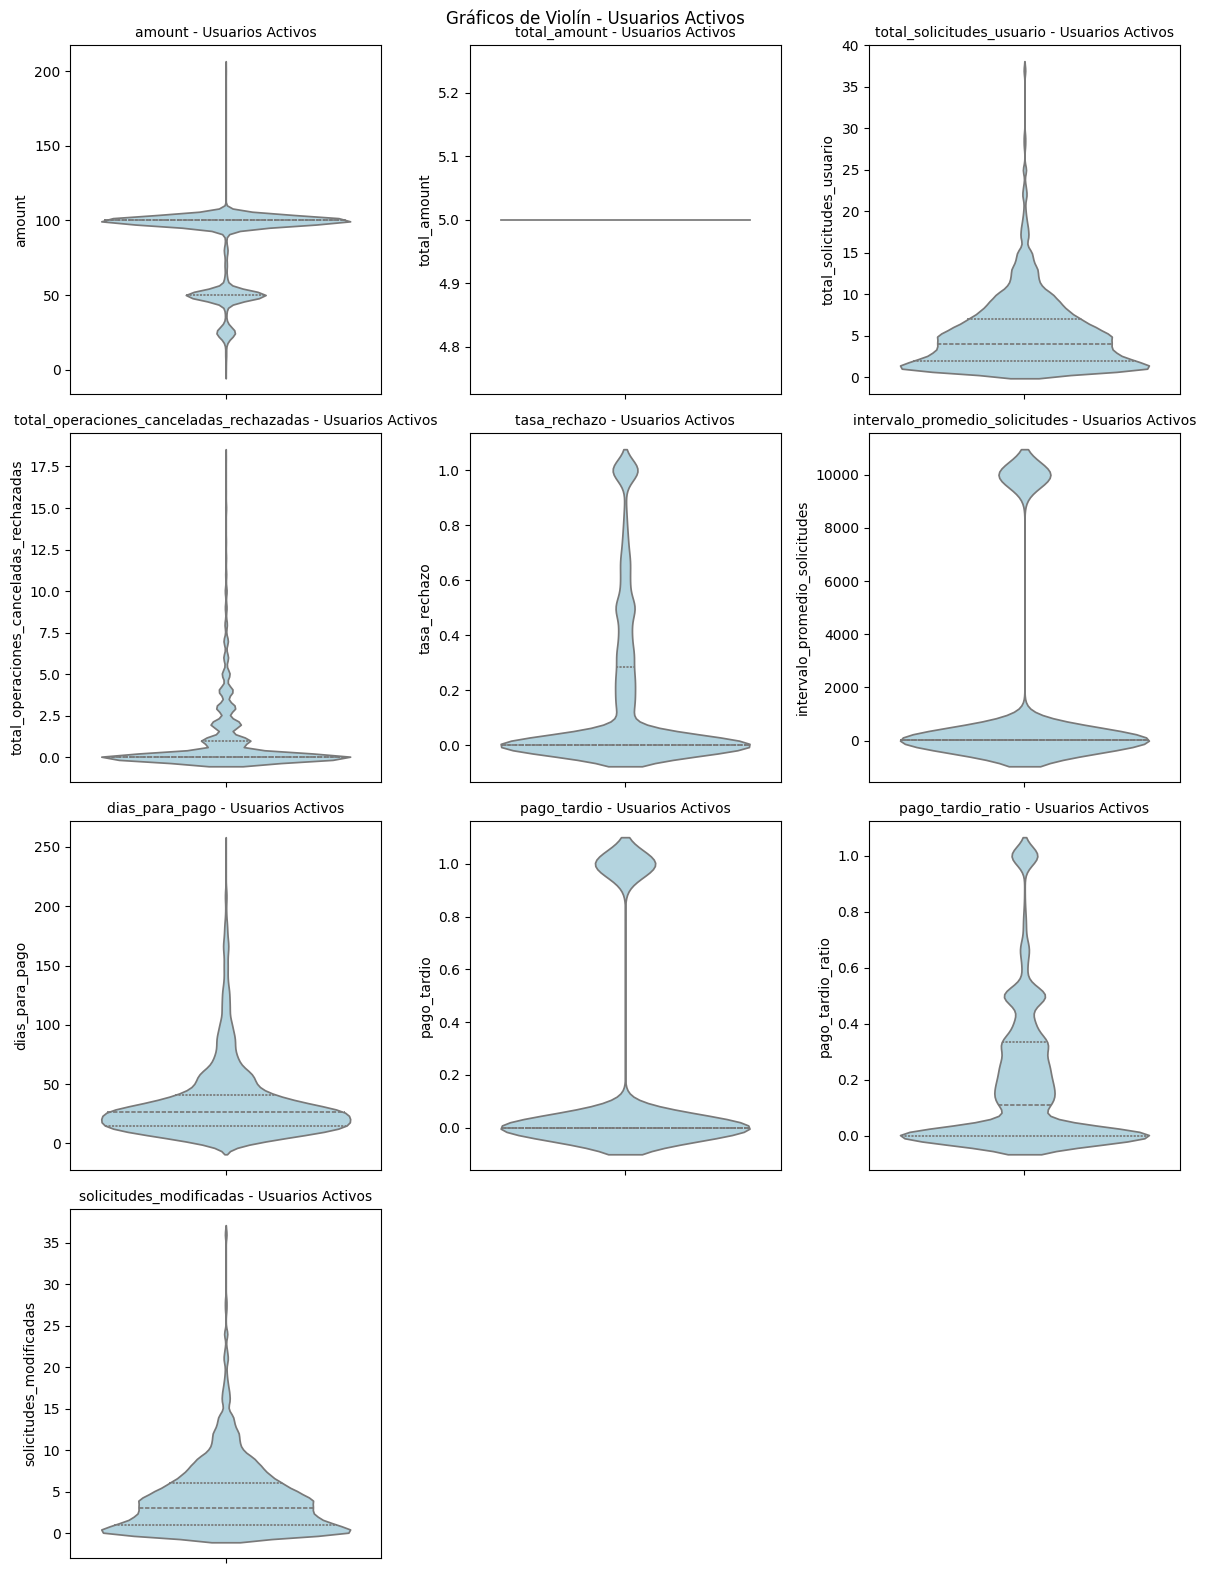

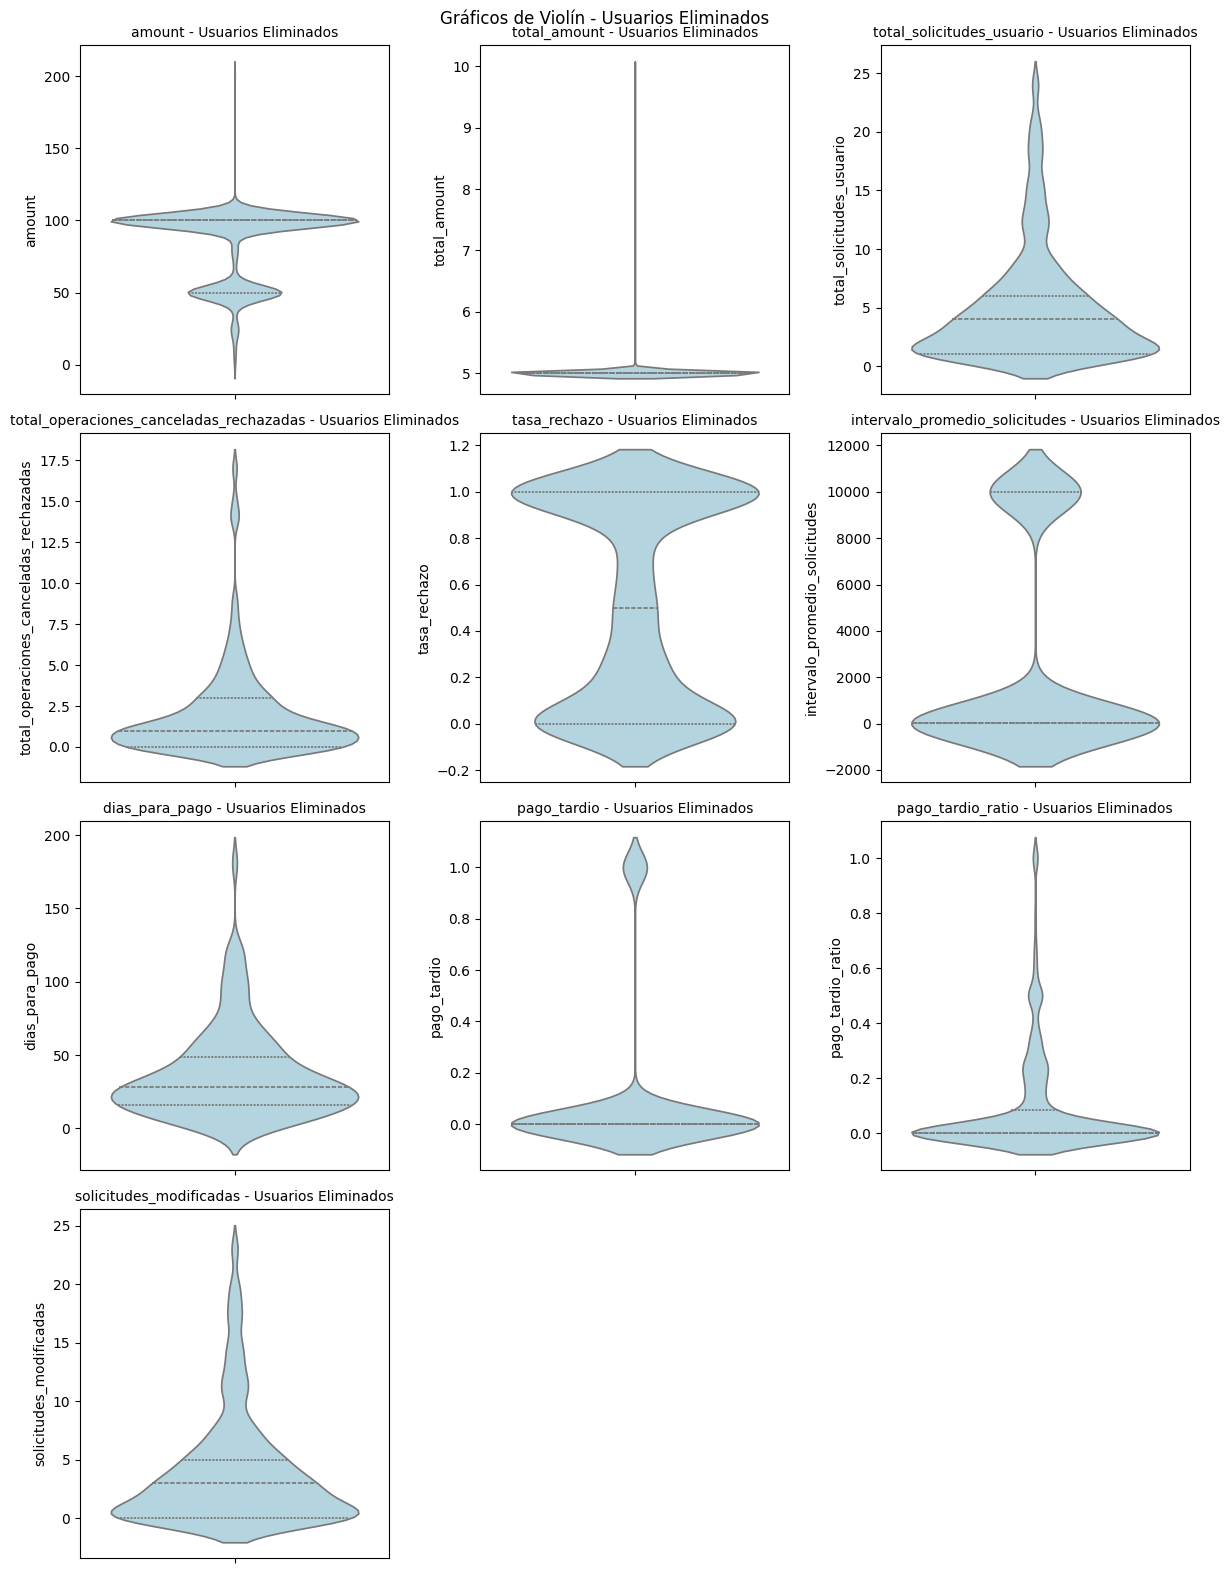

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Función para graficar violin plots de variables numéricas (excluyendo IDs)
def graficar_violin_plots(df, titulo, max_cols=3):
    # Seleccionar columnas numéricas relevantes (excluyendo IDs)
    columnas_numericas = [col for col in df.select_dtypes(include=['number']).columns
                          if 'id' not in col.lower()]

    if not columnas_numericas:
        print(f"No hay columnas numéricas relevantes en {titulo}")
        return

    num_vars = len(columnas_numericas)
    num_cols = min(num_vars, max_cols)  # Determinar número de columnas
    num_rows = int(np.ceil(num_vars / num_cols))  # Determinar número de filas

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4*num_cols, 4*num_rows))
    axes = np.array(axes).reshape(-1)  # Convertir a 1D para iterar

    for i, columna in enumerate(columnas_numericas):
        sns.violinplot(y=df[columna], ax=axes[i], color='lightblue', inner='quartile')
        axes[i].set_title(f'{columna} - {titulo}', fontsize=10)

    # Ocultar gráficos vacíos si hay menos variables de las esperadas
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Gráficos de Violín - {titulo}', fontsize=12)
    plt.tight_layout()
    plt.show()

# Gráficos de violín para usuarios_activos
graficar_violin_plots(usuarios_activos, 'Usuarios Activos')

# Gráficos de violín para usuarios_eliminados
graficar_violin_plots(usuarios_eliminados, 'Usuarios Eliminados')


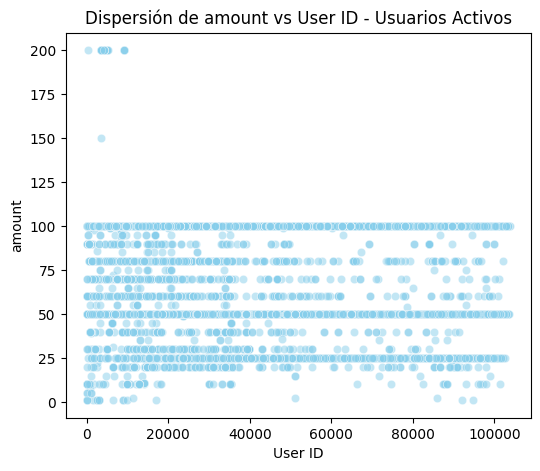

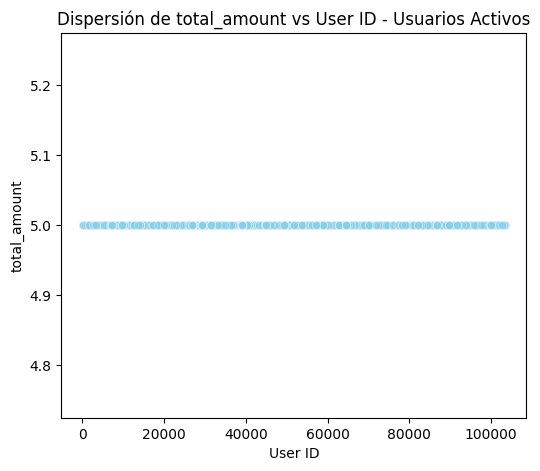

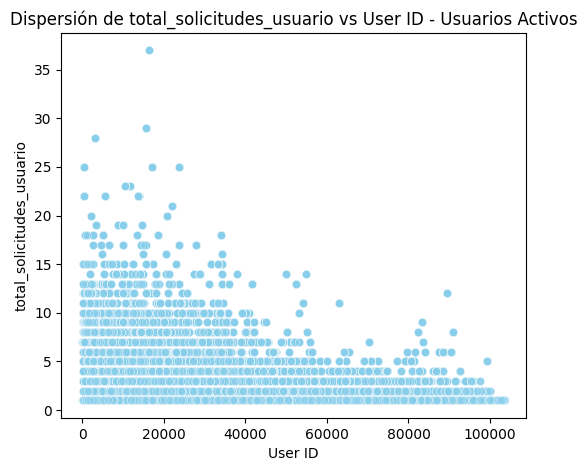

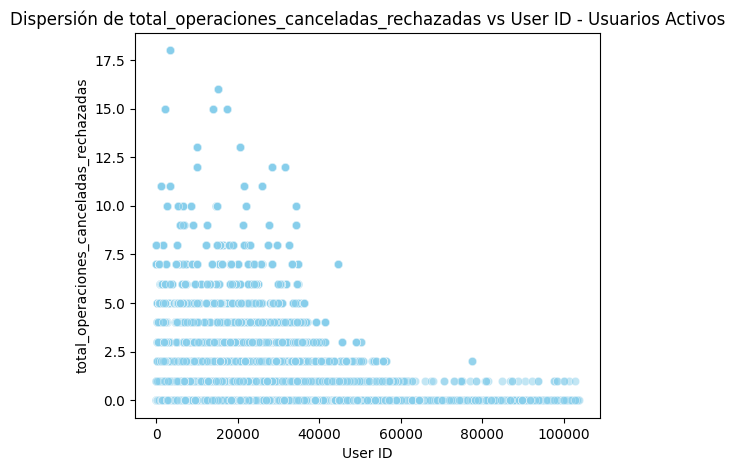

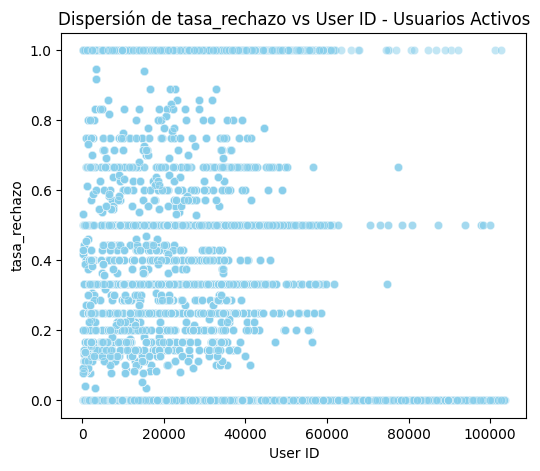

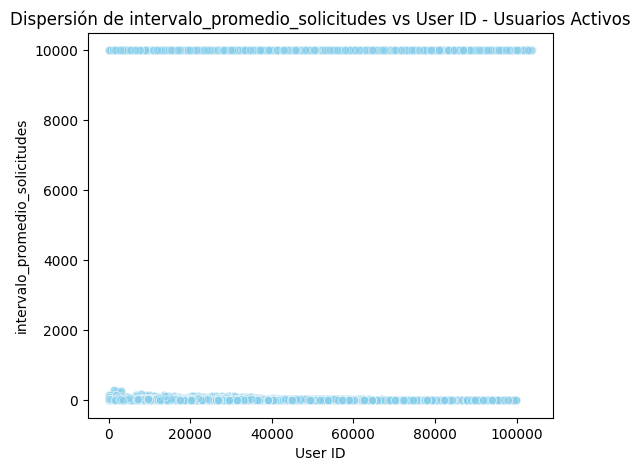

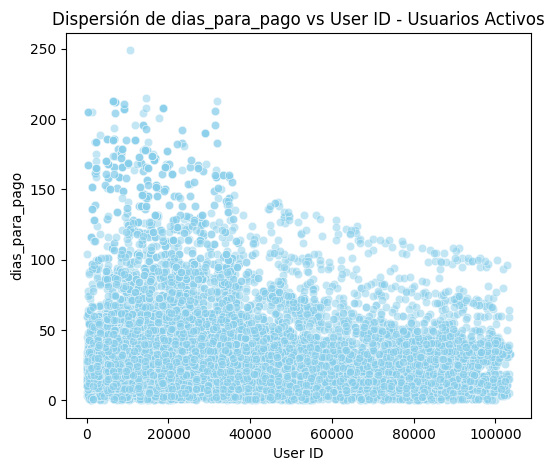

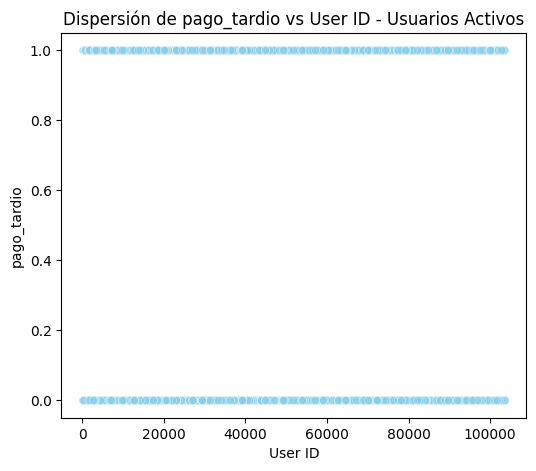

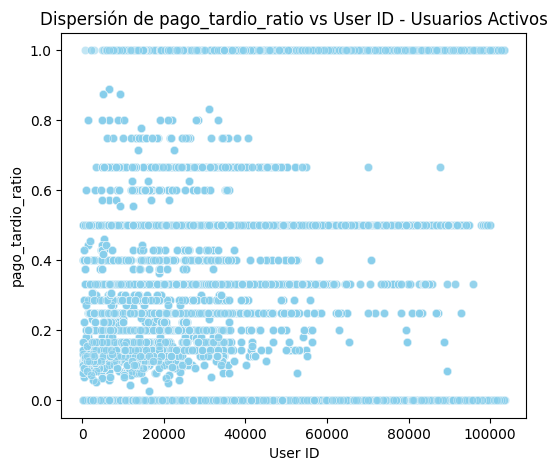

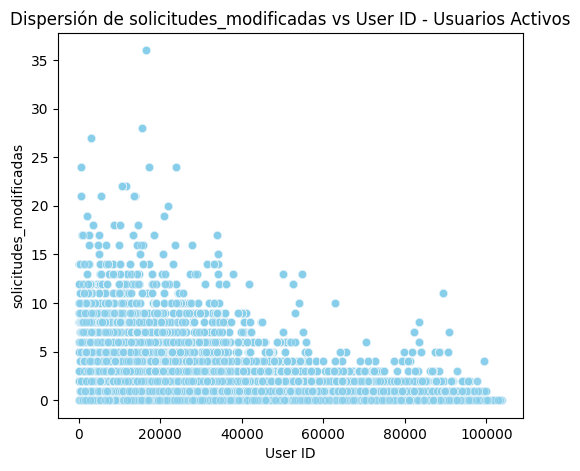

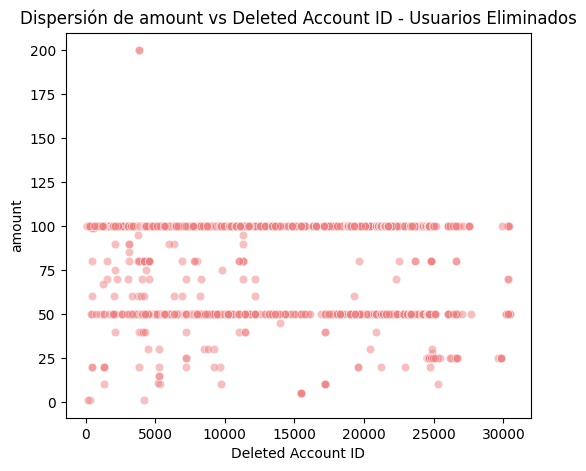

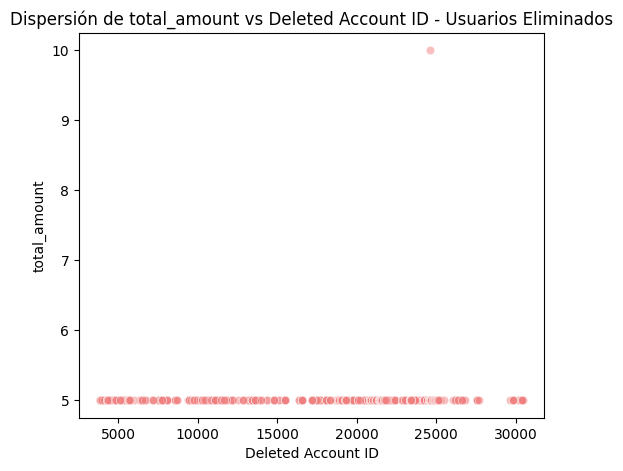

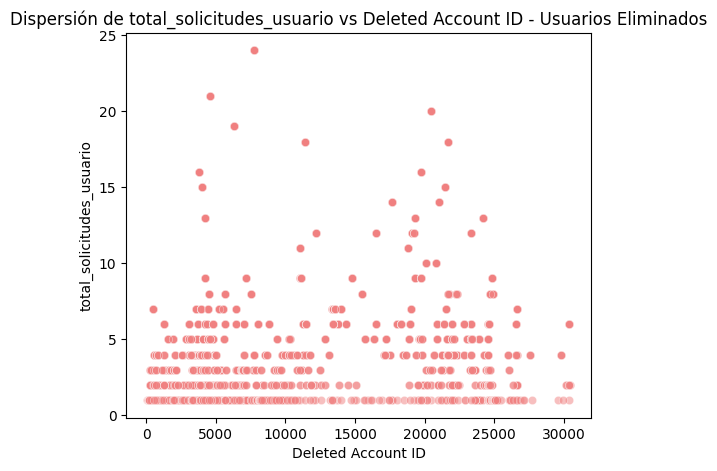

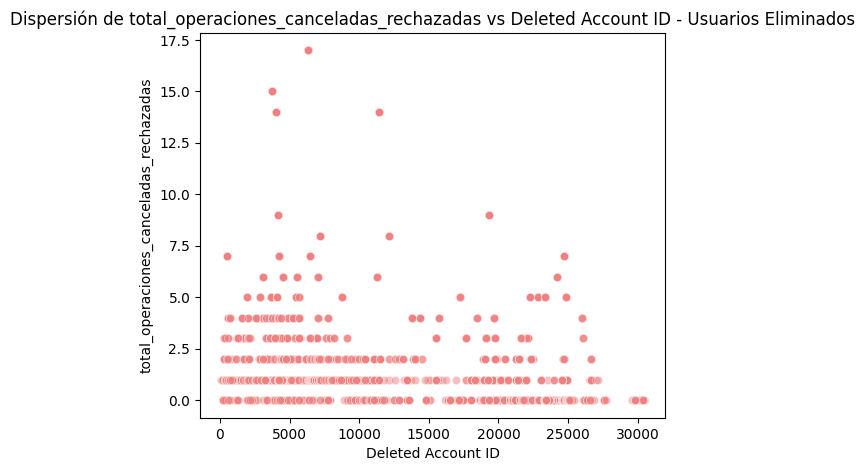

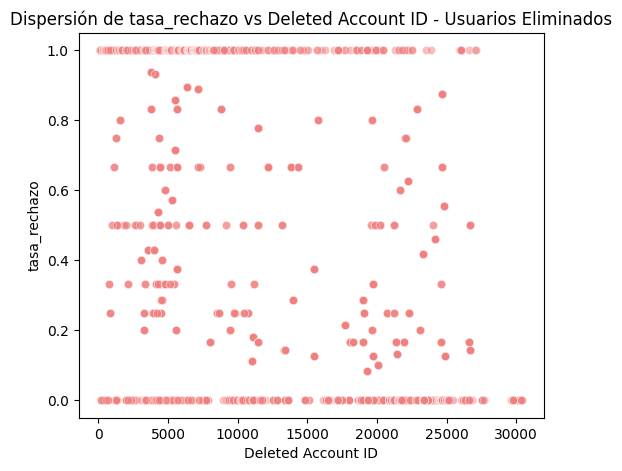

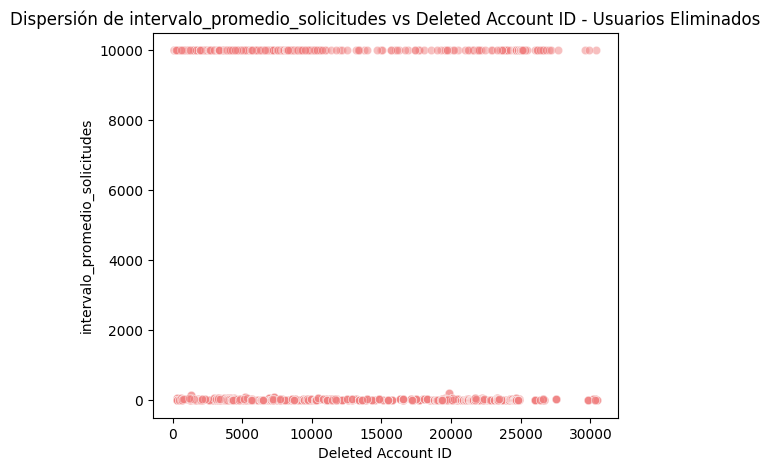

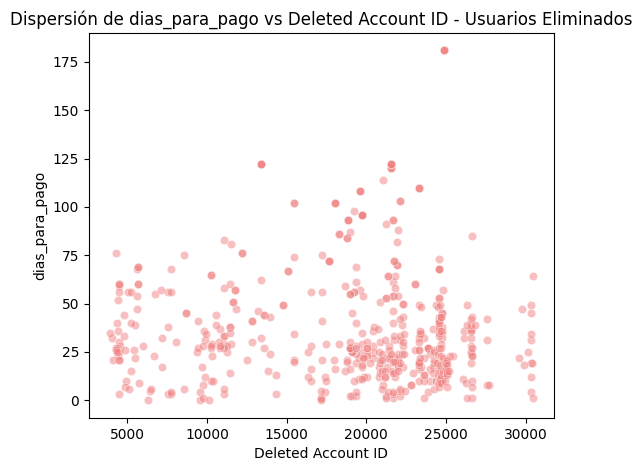

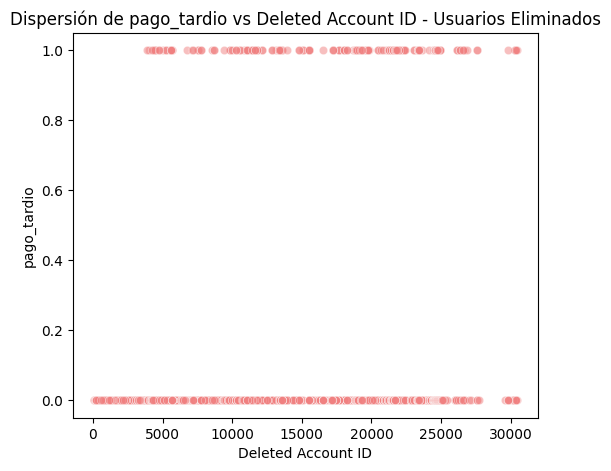

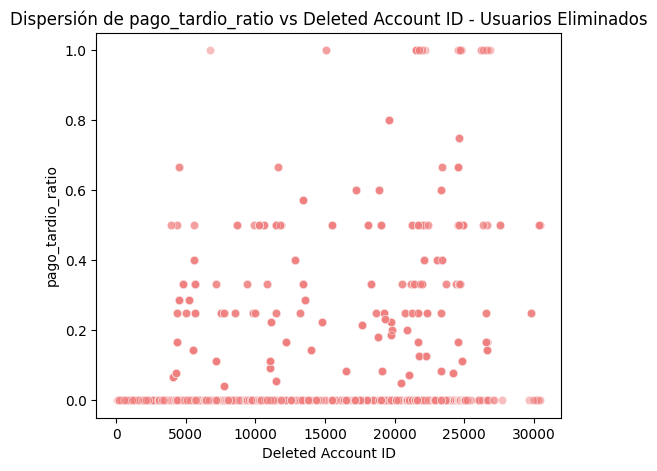

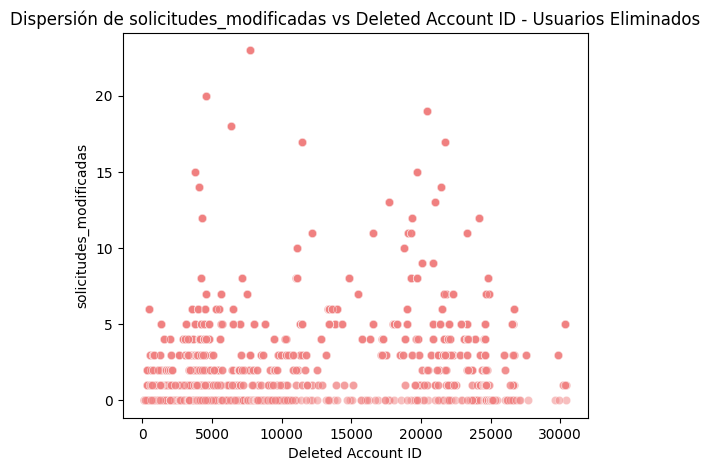

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar variables numéricas relevantes (excluyendo IDs)
variables_relevantes = [col for col in usuarios_activos.select_dtypes(include=['number']).columns
                        if 'id' not in col.lower()]

# Gráficos de dispersión para usuarios_activos
for columna in variables_relevantes:
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=usuarios_activos["user_id"], y=usuarios_activos[columna], color='skyblue', alpha=0.5)
    plt.title(f"Dispersión de {columna} vs User ID - Usuarios Activos")
    plt.xlabel("User ID")
    plt.ylabel(columna)
    plt.show()

# Seleccionar variables numéricas relevantes para usuarios eliminados
variables_relevantes_eliminados = [col for col in usuarios_eliminados.select_dtypes(include=['number']).columns
                                   if 'id' not in col.lower()]

# Gráficos de dispersión para usuarios_eliminados
for columna in variables_relevantes_eliminados:
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=usuarios_eliminados["deleted_account_id"], y=usuarios_eliminados[columna], color='lightcoral', alpha=0.5)
    plt.title(f"Dispersión de {columna} vs Deleted Account ID - Usuarios Eliminados")
    plt.xlabel("Deleted Account ID")
    plt.ylabel(columna)
    plt.show()


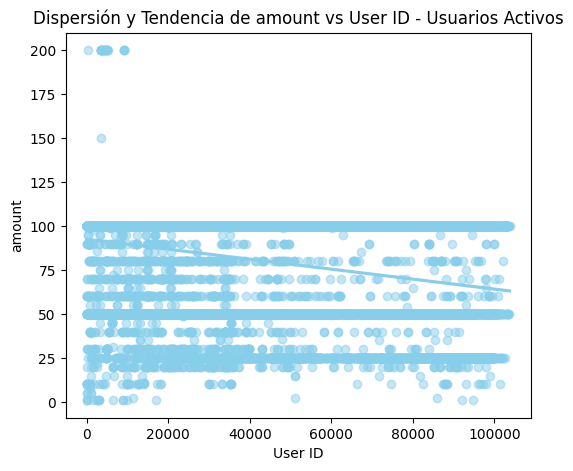

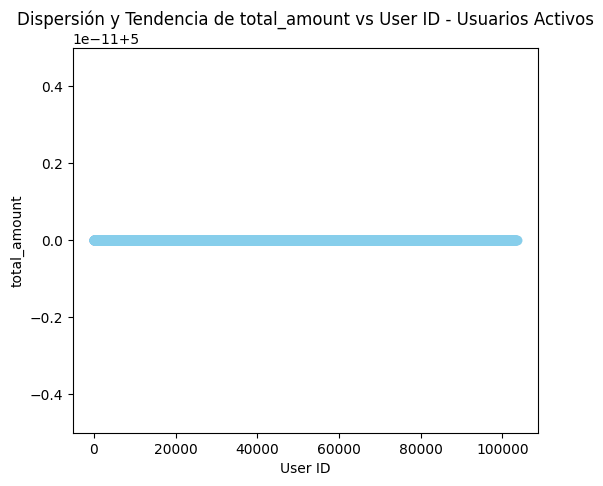

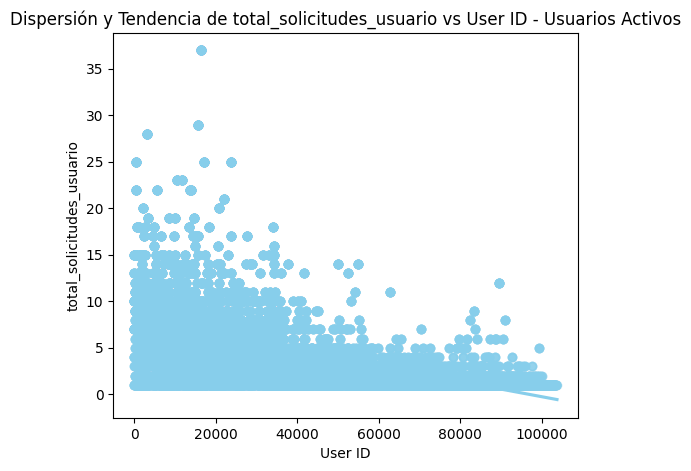

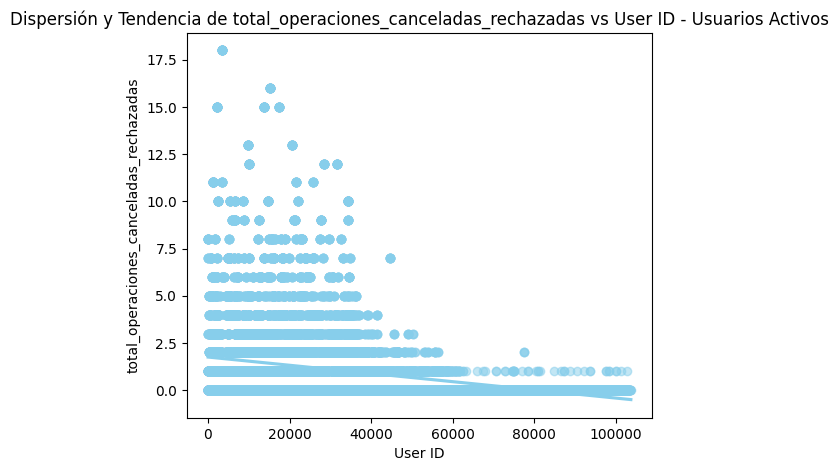

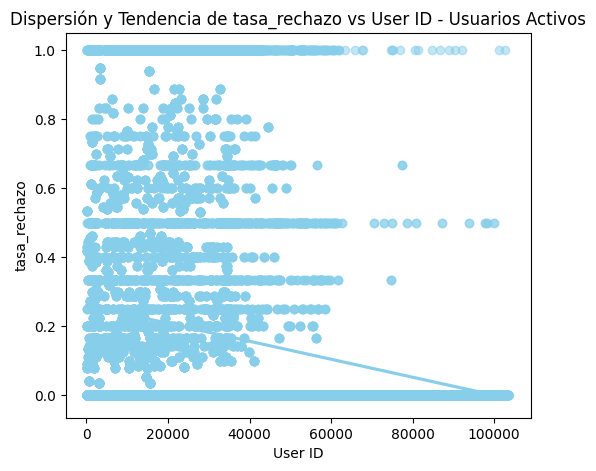

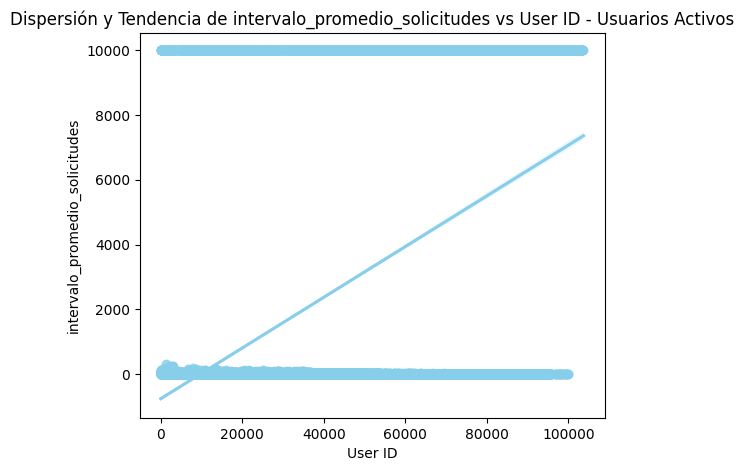

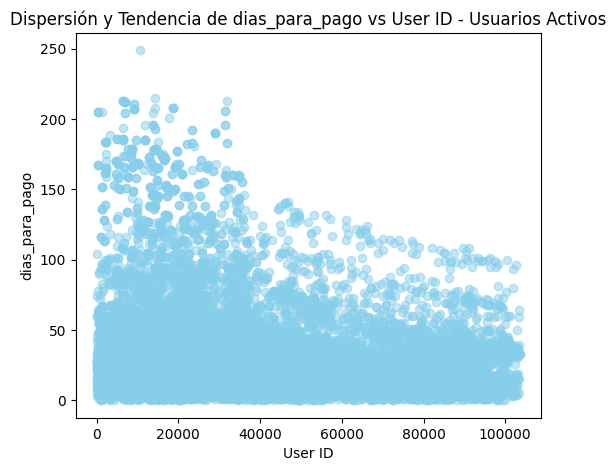

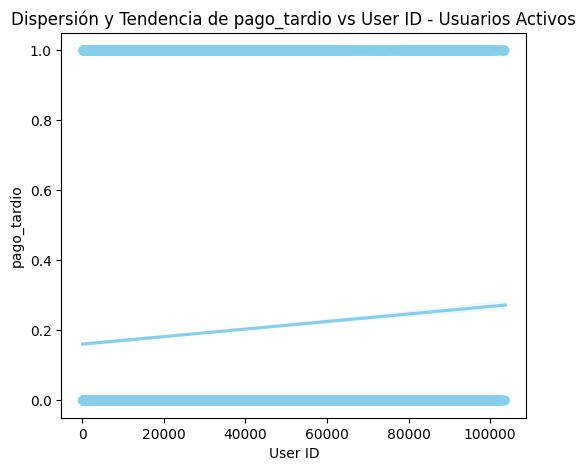

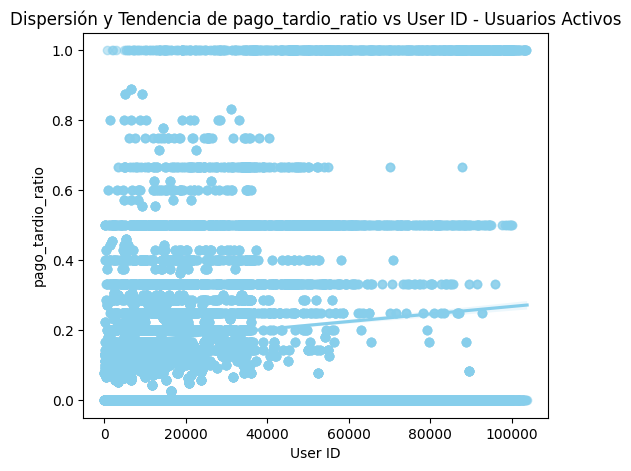

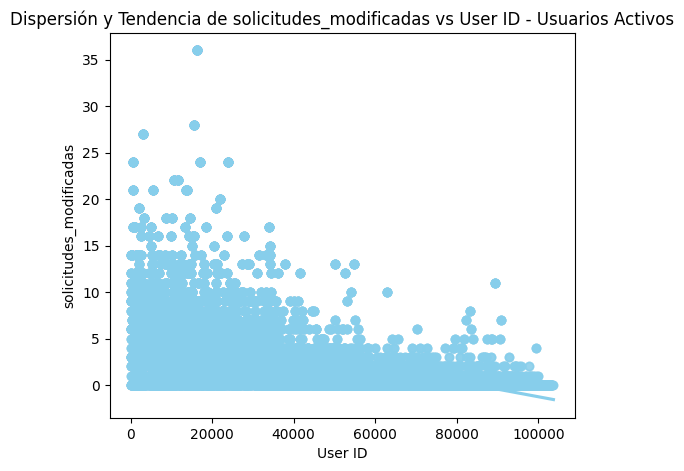

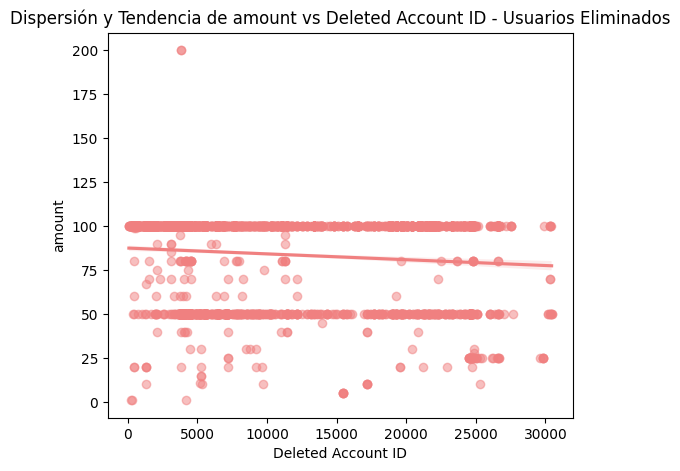

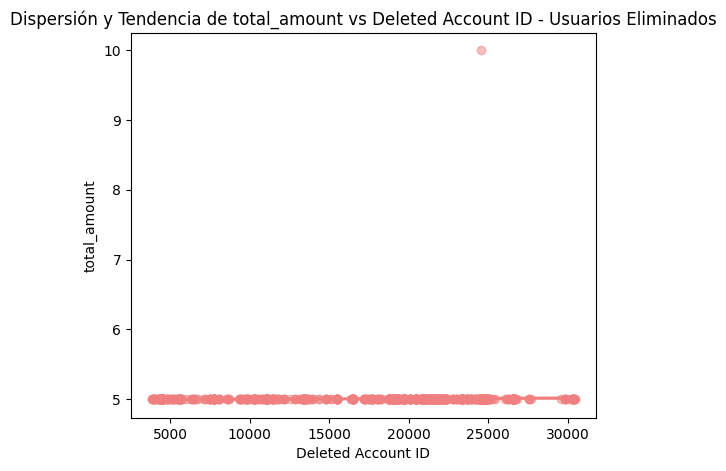

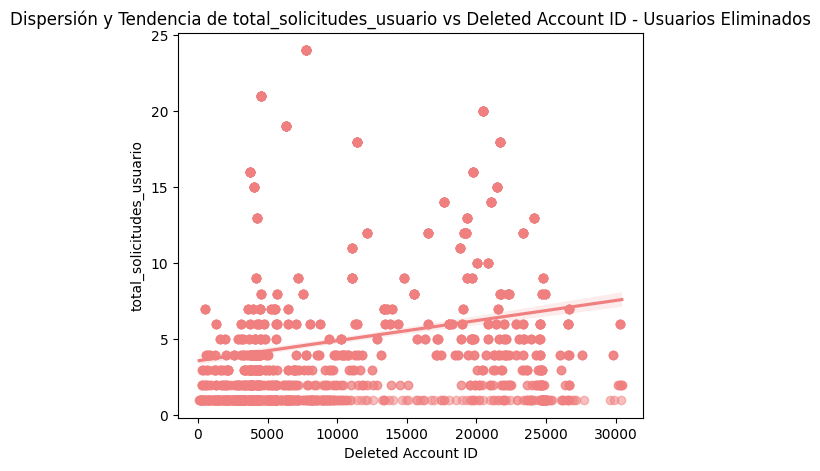

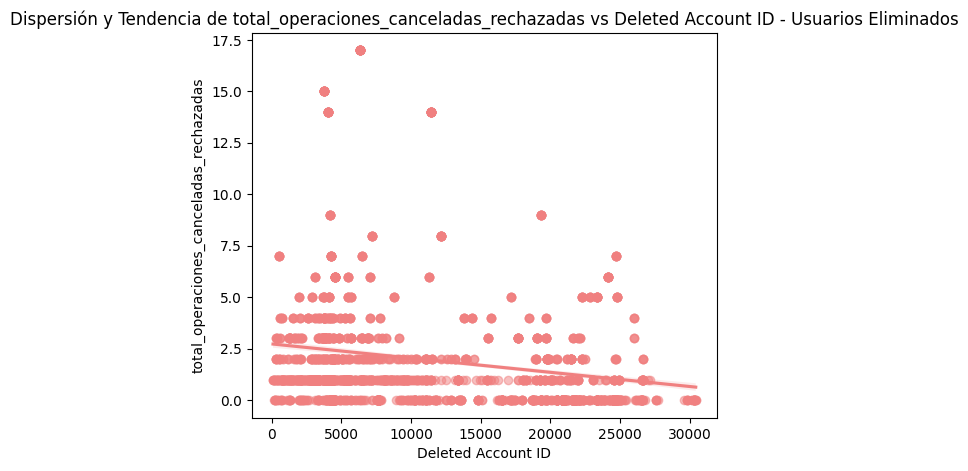

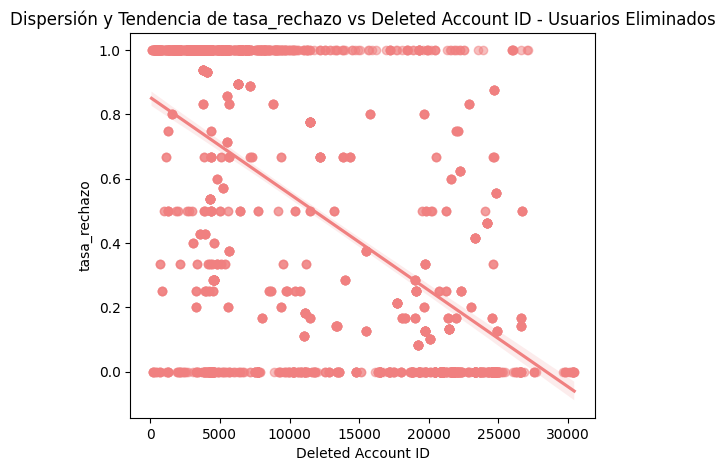

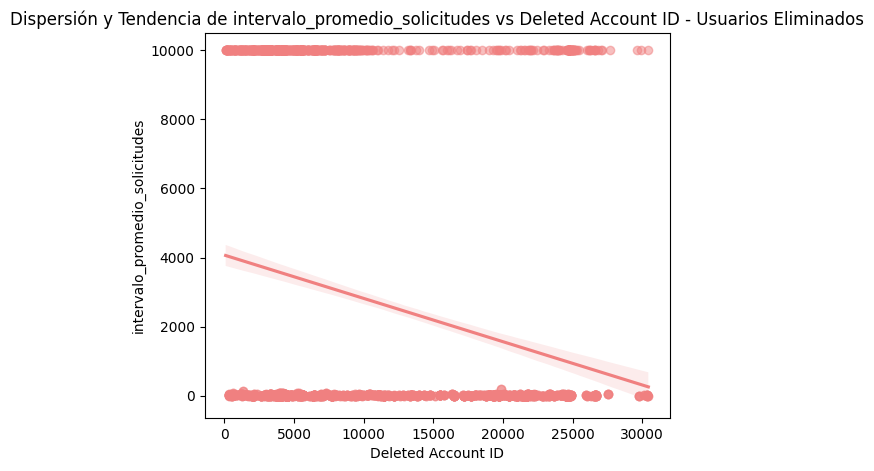

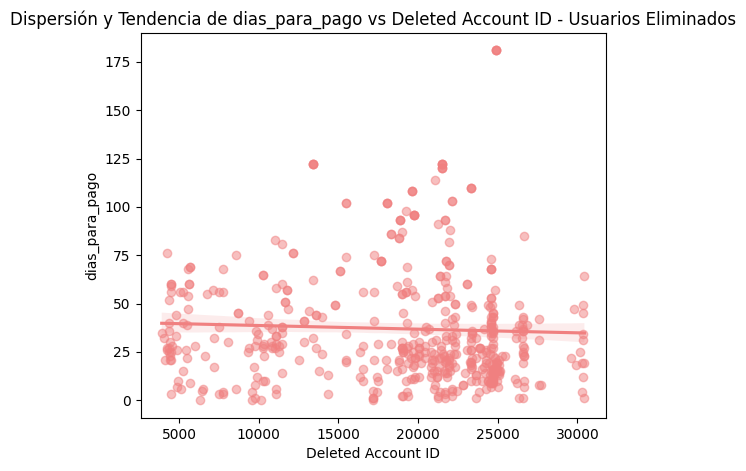

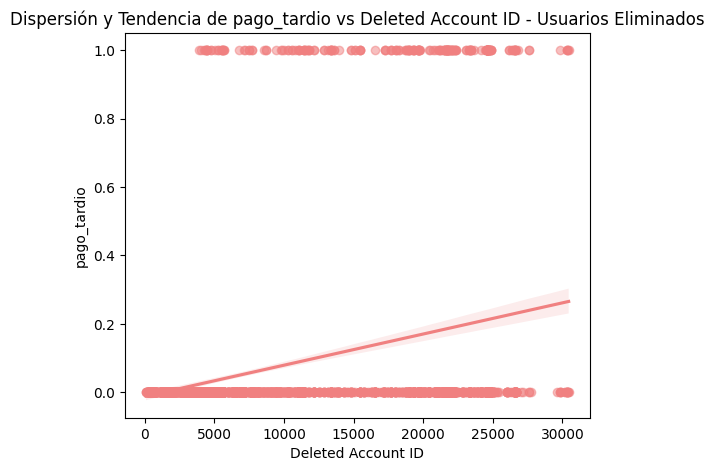

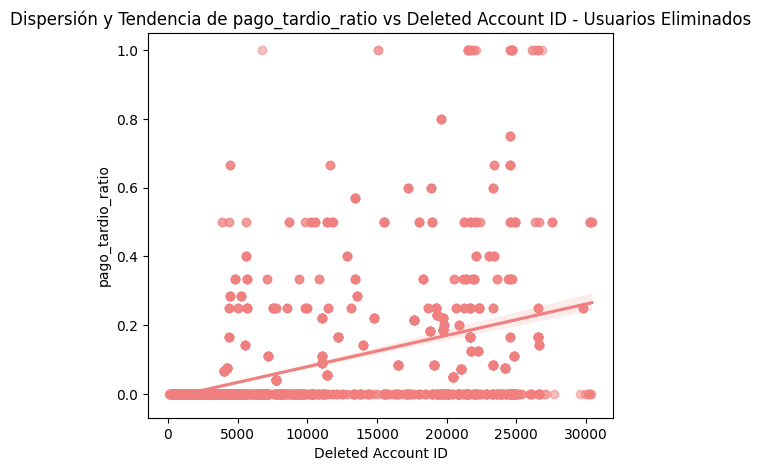

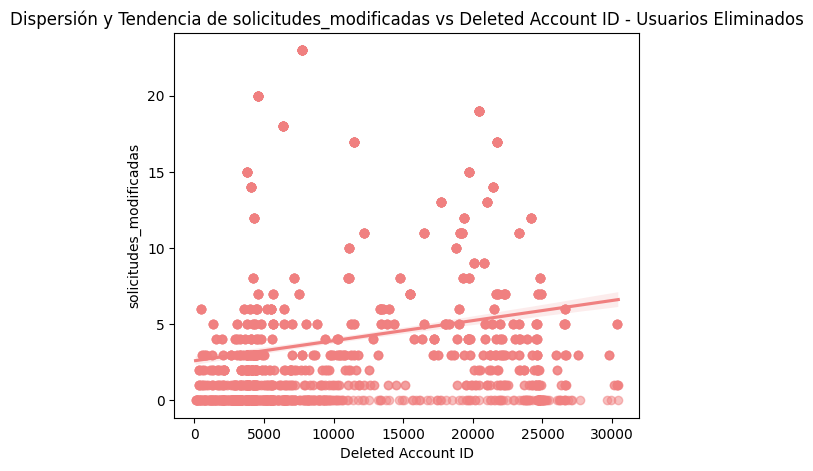

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar variables numéricas relevantes (excluyendo IDs)
variables_relevantes = [col for col in usuarios_activos.select_dtypes(include=['number']).columns
                        if 'id' not in col.lower()]

# Gráficos de dispersión con línea de tendencia para usuarios_activos
for columna in variables_relevantes:
    plt.figure(figsize=(6, 5))
    sns.regplot(x=usuarios_activos["user_id"], y=usuarios_activos[columna], color='skyblue', scatter_kws={'alpha':0.5})
    plt.title(f"Dispersión y Tendencia de {columna} vs User ID - Usuarios Activos")
    plt.xlabel("User ID")
    plt.ylabel(columna)
    plt.show()

# Seleccionar variables numéricas relevantes para usuarios eliminados
variables_relevantes_eliminados = [col for col in usuarios_eliminados.select_dtypes(include=['number']).columns
                                   if 'id' not in col.lower()]

# Gráficos de dispersión con línea de tendencia para usuarios_eliminados
for columna in variables_relevantes_eliminados:
    plt.figure(figsize=(6, 5))
    sns.regplot(x=usuarios_eliminados["deleted_account_id"], y=usuarios_eliminados[columna], color='lightcoral', scatter_kws={'alpha':0.5})
    plt.title(f"Dispersión y Tendencia de {columna} vs Deleted Account ID - Usuarios Eliminados")
    plt.xlabel("Deleted Account ID")
    plt.ylabel(columna)
    plt.show()


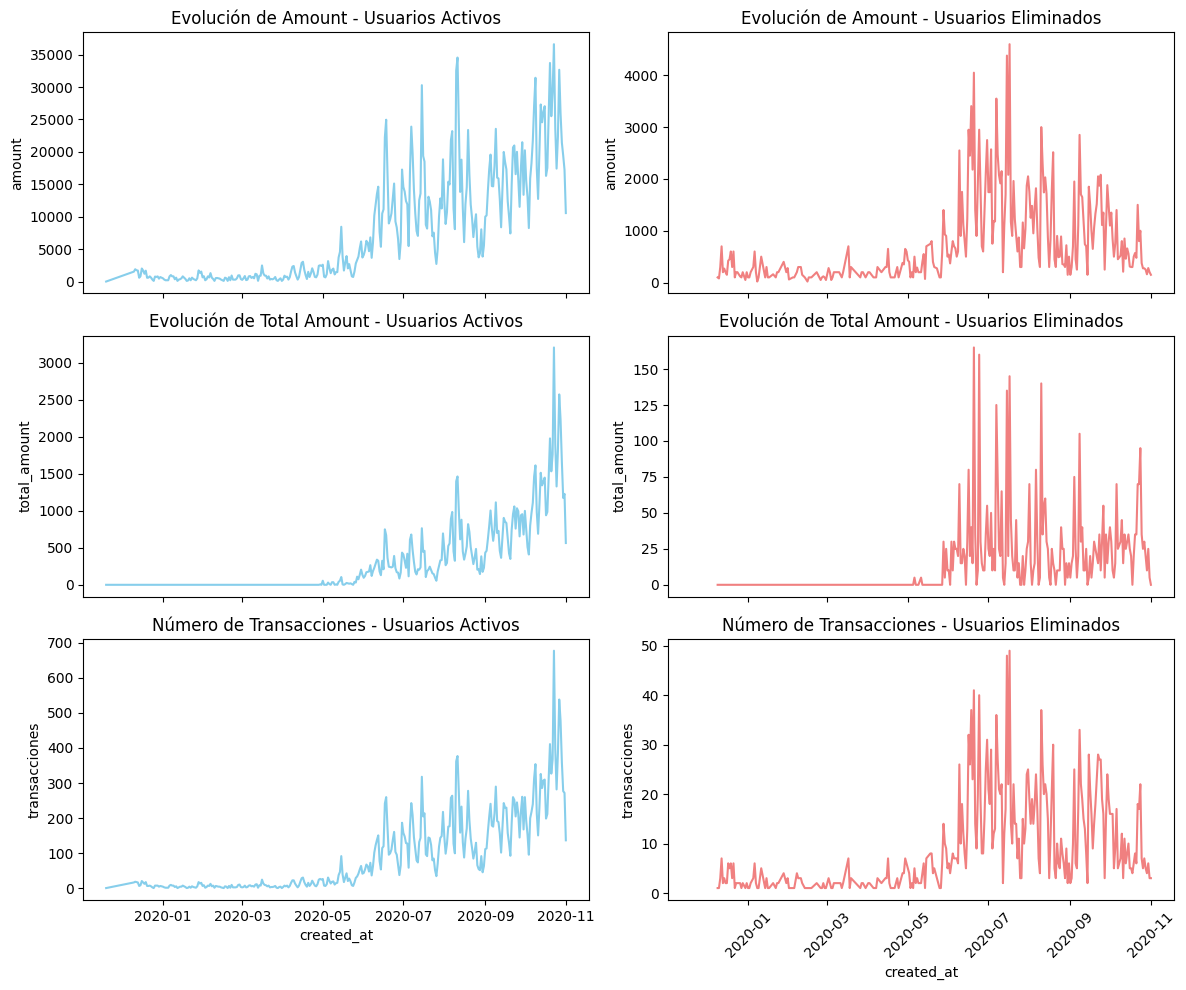

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convertir las columnas de fecha a formato datetime
usuarios_activos["created_at"] = pd.to_datetime(usuarios_activos["created_at"], errors="coerce")
usuarios_eliminados["created_at"] = pd.to_datetime(usuarios_eliminados["created_at"], errors="coerce")

# Agrupar por fecha y calcular métricas relevantes
usuarios_activos_ts = usuarios_activos.groupby(usuarios_activos["created_at"].dt.date).agg({
    "amount": "sum",
    "total_amount": "sum",
    "user_id": "count"  # Cantidad de transacciones por día
}).rename(columns={"user_id": "transacciones"})

usuarios_eliminados_ts = usuarios_eliminados.groupby(usuarios_eliminados["created_at"].dt.date).agg({
    "amount": "sum",
    "total_amount": "sum",
    "deleted_account_id": "count"  # Cantidad de transacciones por día
}).rename(columns={"deleted_account_id": "transacciones"})

# Graficar la evolución de las métricas en el tiempo
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)

# Series temporales para usuarios activos
sns.lineplot(ax=axes[0, 0], x=usuarios_activos_ts.index, y=usuarios_activos_ts["amount"], color='skyblue')
axes[0, 0].set_title("Evolución de Amount - Usuarios Activos")

sns.lineplot(ax=axes[1, 0], x=usuarios_activos_ts.index, y=usuarios_activos_ts["total_amount"], color='skyblue')
axes[1, 0].set_title("Evolución de Total Amount - Usuarios Activos")

sns.lineplot(ax=axes[2, 0], x=usuarios_activos_ts.index, y=usuarios_activos_ts["transacciones"], color='skyblue')
axes[2, 0].set_title("Número de Transacciones - Usuarios Activos")

# Series temporales para usuarios eliminados
sns.lineplot(ax=axes[0, 1], x=usuarios_eliminados_ts.index, y=usuarios_eliminados_ts["amount"], color='lightcoral')
axes[0, 1].set_title("Evolución de Amount - Usuarios Eliminados")

sns.lineplot(ax=axes[1, 1], x=usuarios_eliminados_ts.index, y=usuarios_eliminados_ts["total_amount"], color='lightcoral')
axes[1, 1].set_title("Evolución de Total Amount - Usuarios Eliminados")

sns.lineplot(ax=axes[2, 1], x=usuarios_eliminados_ts.index, y=usuarios_eliminados_ts["transacciones"], color='lightcoral')
axes[2, 1].set_title("Número de Transacciones - Usuarios Eliminados")

# Ajustar el diseño
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
